In [1]:
import pandas as pd
# auto reload
%load_ext autoreload
%autoreload 2

# Without Feature Engineering

In [2]:
data = pd.read_csv('./merged_data.csv', low_memory=False)
data

,X,Y,Z,EDA,HR,TEMP,id,datetime,label
0,-13.0,-61.0,5.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.000000000,2.0
1,-20.0,-69.0,-3.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.031249920,2.0
2,-31.0,-78.0,-15.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.062500096,2.0
3,-47.0,-65.0,-38.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.093750016,2.0
4,-67.0,-57.0,-53.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.124999936,2.0
...,...,...,...,...,...,...,...,...,...
11509046,-16.0,-56.0,24.0,3.386070,88.37,33.77,F5,2020-07-23 17:28:59.875000064,2.0
11509047,-8.0,-50.0,27.0,3.386070,88.37,33.77,F5,2020-07-23 17:28:59.906249984,2.0
11509048,-28.0,-36.0,28.0,3.386070,88.37,33.77,F5,2020-07-23 17:28:59.937499904,2.0
11509049,-29.0,-29.0,30.0,3.386070,88.37,33.77,F5,2020-07-23 17:28:59.968750080,2.0


In [3]:
data.isnull().sum()

X           0
Y           0
Z           0
EDA         0
HR          0
TEMP        0
id          0
datetime    0
label       0
dtype: int64

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11509051 entries, 0 to 11509050
Data columns (total 9 columns):
 #   Column    Dtype  
---  ------    -----  
 0   X         float64
 1   Y         float64
 2   Z         float64
 3   EDA       float64
 4   HR        float64
 5   TEMP      float64
 6   id        object 
 7   datetime  object 
 8   label     float64
dtypes: float64(7), object(2)
memory usage: 790.3+ MB


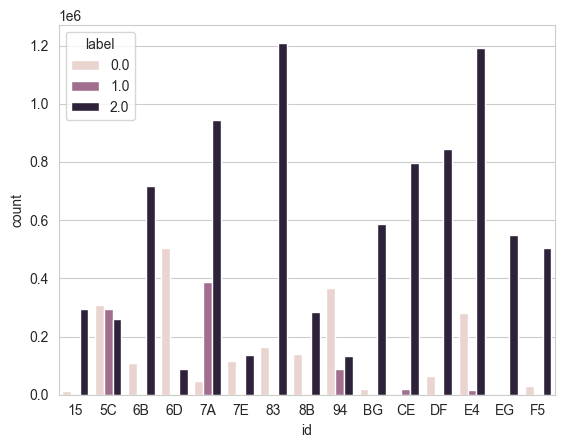

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=data["id"], hue=data["label"])
plt.show()

In [23]:
# Remove ids "CE" and "EG" due to lack of data
data = data[~data["id"].isin(["CE", "EG"])]

In [29]:
# Binary classification
data.loc[data['label'] == 2, 'label'] = 1

## Centralized Learning

In [44]:
x = data.drop(columns=["label", "id", "datetime"])
y = data["label"]

In [45]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

In [46]:
# standard scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

### XGBoost

In [39]:
# train xgboost
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(x_train, y_train)

# get f1_score
y_pred = model.predict(x_test)

In [40]:
# f1 score from sklearn
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f1)

0.957616273400936


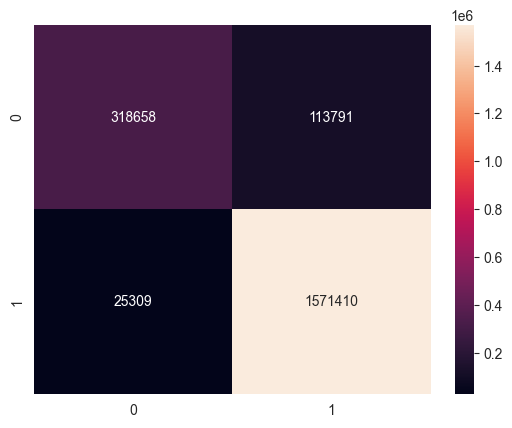

In [41]:
# Draw confuion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

### Keras

In [47]:
# train keras model
import keras

model = keras.Sequential()
model.add(keras.layers.Input(shape=(x_train.shape[1],)))
model.add(keras.layers.Dense(512))
model.add(keras.layers.LeakyReLU())
model.add(keras.layers.Dense(256))
model.add(keras.layers.LeakyReLU())
model.add(keras.layers.Dense(128))
model.add(keras.layers.LeakyReLU())
model.add(keras.layers.Dense(64))
model.add(keras.layers.LeakyReLU())
model.add(keras.layers.Dense(50))
model.add(keras.layers.LeakyReLU())
model.add(keras.layers.Dense(1, activation="sigmoid"))

optimizer = keras.optimizers.Adam()
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

early_stopping_callback = keras.callbacks.EarlyStopping(patience=10, monitor="val_loss", min_delta=0.001)
reduce_lr_callback = keras.callbacks.ReduceLROnPlateau(patience=7, monitor="val_loss", factor=0.2)

model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2, callbacks=[early_stopping_callback, reduce_lr_callback])

Epoch 1/10
50730/50730 ━━━━━━━━━━━━━━━━━━━━ 176s 3ms/step - accuracy: 0.8609 - loss: 0.3307 - val_accuracy: 0.9078 - val_loss: 0.2352 - learning_rate: 0.0010
Epoch 2/10
50730/50730 ━━━━━━━━━━━━━━━━━━━━ 179s 4ms/step - accuracy: 0.9139 - loss: 0.2164 - val_accuracy: 0.9261 - val_loss: 0.1875 - learning_rate: 0.0010
Epoch 3/10
50730/50730 ━━━━━━━━━━━━━━━━━━━━ 175s 3ms/step - accuracy: 0.9263 - loss: 0.1883 - val_accuracy: 0.9255 - val_loss: 0.1901 - learning_rate: 0.0010
Epoch 4/10
50730/50730 ━━━━━━━━━━━━━━━━━━━━ 171s 3ms/step - accuracy: 0.9331 - loss: 0.1727 - val_accuracy: 0.9367 - val_loss: 0.1667 - learning_rate: 0.0010
Epoch 5/10
50730/50730 ━━━━━━━━━━━━━━━━━━━━ 174s 3ms/step - accuracy: 0.9374 - loss: 0.1621 - val_accuracy: 0.9361 - val_loss: 0.1658 - learning_rate: 0.0010
Epoch 6/10
50730/50730 ━━━━━━━━━━━━━━━━━━━━ 170s 3ms/step - accuracy: 0.9406 - loss: 0.1547 - val_accuracy: 0.9463 - val_loss: 0.1417 - learning_rate: 0.0010
Epoch 7/10
50730/50730 ━━━━━━━━━━━━━━━━━━━━ 167s 3ms

In [49]:
from sklearn.metrics import f1_score
import numpy as np
y_pred = model.predict(x_test)
f1 = f1_score(y_test, y_pred > 0.5)
f1

63412/63412 ━━━━━━━━━━━━━━━━━━━━ 29s 464us/step


0.9687426542453822

## Individual Learning

### XGBoost

In [42]:
# standard scaling
from sklearn.preprocessing import StandardScaler

f1_scores = list()
for participant in data["id"].unique():
    participant_data = data[data["id"] == participant]
    x = participant_data.drop(columns=["label", "id", "datetime"])
    y = participant_data["label"]
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)

    model = XGBClassifier()
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    f1 = f1_score(y_test, y_pred)
    print(f"Participant: {participant}, F1 Score: {f1}")
    f1_scores.append(f1)

# print average f1 score
average_f1 = sum(f1_scores) / len(f1_scores)
average_f1

Participant: 15, F1 Score: 0.9999577263542362
Participant: 5C, F1 Score: 0.9990255555904819
Participant: 6B, F1 Score: 0.9978869390554235
Participant: 6D, F1 Score: 0.9999716946417957
Participant: 7A, F1 Score: 0.9998009606465399
Participant: 7E, F1 Score: 1.0
Participant: 83, F1 Score: 0.9977474733919004
Participant: 8B, F1 Score: 0.9991856891433976
Participant: 94, F1 Score: 0.9973278753766559
Participant: BG, F1 Score: 1.0
Participant: DF, F1 Score: 0.9996826837246406
Participant: E4, F1 Score: 0.9994531919917482
Participant: F5, F1 Score: 1.0


0.9992338299936014

### Keras

In [51]:
f1_scores = list()
for participant in data["id"].unique():
    participant_data = data[data["id"] == participant]
    x = participant_data.drop(columns=["label", "id", "datetime"])
    y = participant_data["label"]
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(x_train.shape[1],)))
    model.add(keras.layers.Dense(512))
    model.add(keras.layers.LeakyReLU())
    model.add(keras.layers.Dense(256))
    model.add(keras.layers.LeakyReLU())
    model.add(keras.layers.Dense(128))
    model.add(keras.layers.LeakyReLU())
    model.add(keras.layers.Dense(64))
    model.add(keras.layers.LeakyReLU())
    model.add(keras.layers.Dense(50))
    model.add(keras.layers.LeakyReLU())
    model.add(keras.layers.Dense(1, activation="sigmoid"))

    optimizer = keras.optimizers.Adam()
    model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

    early_stopping_callback = keras.callbacks.EarlyStopping(patience=10, monitor="val_loss", min_delta=0.001)
    reduce_lr_callback = keras.callbacks.ReduceLROnPlateau(patience=7, monitor="val_loss", factor=0.2)

    model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2, callbacks=[early_stopping_callback, reduce_lr_callback], verbose=0)

    y_pred = model.predict(x_test, verbose=0)
    f1 = f1_score(y_test, y_pred > 0.5)
    print(f"Participant: {participant}, F1 Score: {f1}")
    f1_scores.append(f1)

# print average f1 score
average_f1 = sum(f1_scores) / len(f1_scores)
average_f1

Participant: 15, F1 Score: 0.9914092241350267
Participant: 5C, F1 Score: 0.9611514650336366
Participant: 6B, F1 Score: 0.9685172972824444
Participant: 6D, F1 Score: 0.9214748760669972
Participant: 7A, F1 Score: 0.988017297385846
Participant: 7E, F1 Score: 0.924035142194378
Participant: 83, F1 Score: 0.9810015710515777
Participant: 8B, F1 Score: 0.9290610851080097
Participant: 94, F1 Score: 0.8703626417009757
Participant: BG, F1 Score: 0.9954503399512779
Participant: DF, F1 Score: 0.9902446380994343
Participant: E4, F1 Score: 0.9840068730793378
Participant: F5, F1 Score: 0.9982481838516202


0.961767741149274

# With Feature Engineering

In [2]:
data = pd.read_csv('./nurse_features.csv', engine="pyarrow")
data

,Participant,Label,SCR_Peaks_N,SCR_Peaks_Amplitude_Mean,EDA_Tonic_SD,EDA_Sympathetic,EDA_SympatheticN,EDA_Autocorrelation,EDA_mean,EDA_median,...,Wavelet_4Hz_ACC_Z_min,Wavelet_4Hz_ACC_Z_max,Wavelet_4Hz_ACC_Z_max_amp,Wavelet_4Hz_ACC_Z_range,Wavelet_4Hz_ACC_Z_var,Wavelet_4Hz_ACC_Z_std_dev,Wavelet_4Hz_ACC_Z_abs_dev,Wavelet_4Hz_ACC_Z_rms,Wavelet_4Hz_ACC_Z_kurtosis,Wavelet_4Hz_ACC_Z_skew
0,15,2.0,54.0,0.203682,0.880683,0.014325,0.013667,0.901712,3.345934,3.718497,...,-33.234019,23.334524,33.165518,56.568542,13.605835,3.688609,1.985055,3.687323,15.055447,-0.416561
1,15,2.0,54.0,0.203644,0.855313,0.014214,0.014320,0.896580,3.362750,3.723296,...,-33.234019,23.334524,33.166254,56.568542,13.603328,3.688269,1.982845,3.686970,15.062412,-0.417324
2,15,2.0,53.0,0.206666,0.829843,0.013968,0.014829,0.889135,3.379433,3.726500,...,-33.234019,23.334524,33.164781,56.568542,13.603126,3.688242,1.982845,3.686970,15.062279,-0.416147
3,15,2.0,54.0,0.203467,0.808360,0.013614,0.014867,0.890523,3.396661,3.730344,...,-33.234019,23.334524,33.166991,56.568542,13.607077,3.688777,1.985055,3.687465,15.052841,-0.417641
4,15,2.0,53.0,0.198148,0.779330,0.013189,0.014388,0.896557,3.414556,3.734189,...,-33.234019,23.334524,33.164045,56.568542,13.605630,3.688581,1.983582,3.687323,15.055341,-0.415341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1359859,F5,2.0,39.0,0.071399,0.370948,0.002148,0.001132,0.946438,3.730258,3.847326,...,-48.083261,36.769553,48.092100,84.852814,32.197002,5.674240,2.984580,5.671291,17.297202,-1.025291
1359860,F5,2.0,41.0,0.070178,0.368940,0.002266,0.001232,0.947798,3.725732,3.842843,...,-48.083261,36.769553,48.081788,84.852814,32.265900,5.680308,2.994892,5.677349,17.205907,-1.018706
1359861,F5,2.0,41.0,0.071045,0.366403,0.002330,0.001299,0.948675,3.721407,3.840922,...,-48.083261,36.769553,48.089890,84.852814,32.358142,5.688422,3.008887,5.685462,17.100720,-1.015733
1359862,F5,2.0,41.0,0.071071,0.364120,0.002335,0.001365,0.948405,3.717102,3.830036,...,-48.083261,36.769553,48.079578,84.852814,32.418652,5.693738,3.017726,5.690773,17.020361,-1.009270


In [3]:
data = data.fillna(0)
# Remove ids "CE" and "EG" due to lack of data
data = data[~data["Participant"].isin(["CE", "EG"])]
# Binary classification
data.loc[data['Label'] == 2, 'Label'] = 1

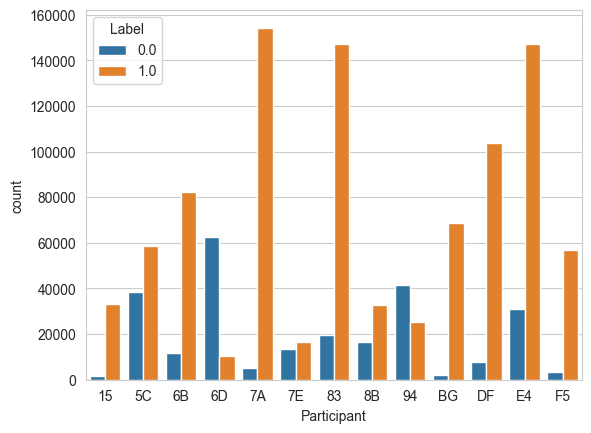

In [4]:
# pplot data. x axis are participants bar plots. The bar plots should be colored by the label. y axis is the amount of data (which shows the amount of labels for each participant)
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=data["Participant"], hue=data["Label"])
plt.show()

In [6]:
x = data.drop(columns=["Label", "Participant"])
y = data["Label"]

In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

In [8]:
# scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

### XGBoost

In [9]:
# train xgboost
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(x_train, y_train)

/Users/cedric/miniconda3/envs/project_2/lib/python3.10/site-packages/sklearn/utils/_tags.py:354: FutureWarning: The XGBClassifier or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [10]:
from sklearn.metrics import f1_score

y_pred = model.predict(x_test)
f1 = f1_score(y_test, y_pred)
f1

0.9993118825612904

In [16]:
# train keras model
import keras

model = keras.Sequential()
model.add(keras.layers.Input(shape=(x_train.shape[1],)))
model.add(keras.layers.Dense(512))
model.add(keras.layers.LeakyReLU())
model.add(keras.layers.Dense(256))
model.add(keras.layers.LeakyReLU())
model.add(keras.layers.Dense(128))
model.add(keras.layers.LeakyReLU())
model.add(keras.layers.Dense(64))
model.add(keras.layers.LeakyReLU())
model.add(keras.layers.Dense(32))
model.add(keras.layers.LeakyReLU())
model.add(keras.layers.Dense(3, activation="softmax"))

optimizer = keras.optimizers.Adam()
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

early_stopping_callback = keras.callbacks.EarlyStopping(patience=10, monitor="val_loss", min_delta=0.001)
reduce_lr_callback = keras.callbacks.ReduceLROnPlateau(patience=7, monitor="val_loss", factor=0.2)

model.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.2, callbacks=[early_stopping_callback, reduce_lr_callback])

Epoch 1/5
6800/6800 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - accuracy: 0.9074 - loss: 0.2538 - val_accuracy: 0.9779 - val_loss: 0.0712 - learning_rate: 0.0010
Epoch 2/5
6800/6800 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - accuracy: 0.9846 - loss: 0.0485 - val_accuracy: 0.9907 - val_loss: 0.0293 - learning_rate: 0.0010
Epoch 3/5
6800/6800 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step - accuracy: 0.9908 - loss: 0.0300 - val_accuracy: 0.9952 - val_loss: 0.0160 - learning_rate: 0.0010
Epoch 4/5
6800/6800 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - accuracy: 0.9926 - loss: 0.0251 - val_accuracy: 0.9967 - val_loss: 0.0113 - learning_rate: 0.0010
Epoch 5/5
6800/6800 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - accuracy: 0.9944 - loss: 0.0188 - val_accuracy: 0.9847 - val_loss: 0.0556 - learning_rate: 0.0010


In [17]:
from sklearn.metrics import f1_score
import numpy as np

y_pred = np.argmax(model.predict(x_test), axis=-1)
f1 = f1_score(y_test, y_pred, average='weighted')
f1

8500/8500 ━━━━━━━━━━━━━━━━━━━━ 7s 791us/step


0.9842300706768516

In [18]:
# get classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.97      0.96      0.96     51372
         1.0       0.99      0.97      0.98     17062
         2.0       0.99      0.99      0.99    203539

    accuracy                           0.98    271973
   macro avg       0.98      0.97      0.98    271973
weighted avg       0.98      0.98      0.98    271973

